# Phase 4: Feature Engineering
## Project: Kataoka Inc. Predictive Maintenance System

---

## Business Context

The baseline model achieved R² of 0.855 but the predicted vs actual scatter
plot revealed a critical limitation: the model learned from robot age
(cumulative hours), not from actual degradation behaviour.

This phase builds 12 temporal features that capture how sensor readings
change over time, specifically volatility, rolling trends, rate of change,
and compound stress indicators.

The EDA confirmed that failure is preceded by instability and irregular
behaviour, not smooth upward trends. These features are designed to capture
exactly that signal.

---

## What This Notebook Builds

**8 rolling features** (7-day window, grouped by robot_id):
- Rolling mean and rolling std for all 4 sensors

**3 short-window features** (24-hour window, grouped by robot_id):
- Rolling std for vibration, temperature, and torque

**4 compound features**:
- Wear trend slope (rate of change in vibration)
- Load stress index (torque x cumulative hours)
- Vibration short-long difference (sudden spike detection)
- Temperature short-long difference (sudden thermal event detection)

**Total: 15 engineered features**

**Output**: data/processed/featured_dataset.csv

---

## Critical Rules (Applied Throughout)

- All rolling windows computed within each robot using groupby(robot_id)
- Data sorted by timestamp before any rolling computation
- No shift(-N) or future-looking operations on any feature
- NaN warm-up rows counted, documented, and dropped before saving
- Row count before and after NaN drop documented explicitly

## Section 1: Imports and Data Loading

We load rul_dataset.csv directly.
This contains only the 17 confirmed failure robots with valid RUL labels.
These are the only robots we can train and evaluate on.

In [56]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Load RUL dataset
# We load rul_dataset.csv which contains only the 17 confirmed failure robots.
# This is the direct output from Phase 2 data engineering.

rul_df = pd.read_csv(
    "../data/processed/rul_dataset.csv",
    parse_dates=["timestamp", "failure_time"]
)

print("RUL dataset loaded.")
print(f"  Shape   : {rul_df.shape}")
print(f"  Robots  : {rul_df['robot_id'].nunique()}")
print(f"  Columns : {rul_df.columns.tolist()}")
print(f"\nRUL range: {rul_df['rul_hours'].min():.0f} to {rul_df['rul_hours'].max():.0f} hours")

RUL dataset loaded.
  Shape   : (15245, 25)
  Robots  : 17
  Columns : ['reading_id', 'robot_id', 'timestamp', 'vibration_level', 'motor_temperature', 'torque_load', 'power_consumption', 'model_type', 'factory_location', 'operating_environment', 'cumulative_hours', 'failure_time', 'rul_hours_raw', 'rul_hours', 'is_failure_robot', 'label_status', 'total_maintenance_count', 'total_downtime_hours', 'avg_downtime_hours', 'repair_count', 'replacement_count', 'lubrication_count', 'calibration_count', 'inspection_count', 'health_risk_label']

RUL range: 0 to 8136 hours


## Section 2: Sort and Prepare

Before computing any rolling features we must sort the data.
This is mandatory. If rows are out of order, rolling windows will
compute across the wrong time periods and produce silently incorrect values.

We sort by robot_id first, then by timestamp within each robot.
This ensures every rolling window looks backward in time correctly.

In [57]:
# Sort by robot and timestamp
# This step is mandatory before any rolling computation.
# Incorrect sort order produces wrong rolling values with no error raised.

feature_df = rul_df.copy()

feature_df = feature_df.sort_values(
    ["robot_id", "timestamp"]
).reset_index(drop=True)

# Verify sort is correct
# For each robot, timestamps must be strictly increasing.
# We check that no robot has a timestamp that is earlier than the previous row.

sort_check = (
    feature_df.groupby("robot_id")["timestamp"]
    .apply(lambda x: x.is_monotonic_increasing)
)

assert sort_check.all(), "Sort failed. Some robots have non-monotonic timestamps."

print("Sort verification passed.")
print(f"  Rows    : {len(feature_df)}")
print(f"  Robots  : {feature_df['robot_id'].nunique()}")
print(f"  All robots have monotonically increasing timestamps: True")
print(f"\nFirst 3 rows for ROB-0007 (sanity check):")
display(feature_df[feature_df["robot_id"] == "ROB-0007"][
    ["robot_id", "timestamp", "cumulative_hours", "rul_hours"]
].head(3))

Sort verification passed.
  Rows    : 15245
  Robots  : 17
  All robots have monotonically increasing timestamps: True

First 3 rows for ROB-0007 (sanity check):


,robot_id,timestamp,cumulative_hours,rul_hours
0,ROB-0007,2023-02-10 00:00:00,0.0000,6816.0000
1,ROB-0007,2023-02-10 06:00:00,6.0000,6810.0000
2,ROB-0007,2023-02-10 12:00:00,12.0000,6804.0000


## Section 3: Rolling Features

We compute rolling mean and rolling standard deviation for all four
sensors over a 7-day window (28 readings at 6-hour intervals).

Rolling mean captures the sustained sensor level over the past week.
This smooths out day-to-day noise and reveals whether a sensor is
trending upward over time.

Rolling std captures sensor volatility over the past week.
This is the primary degradation signal identified in Phase 1 EDA.
A robot approaching failure shows increasing instability, not just
elevated readings. Rolling std is the feature that captures that.

Critical rules applied here:
- groupby(robot_id) ensures no cross-robot contamination
- min_periods=WINDOW ensures only full windows produce values.
  Rows with fewer than 28 readings produce NaN and are dropped.
- All computation looks backward only

In [58]:
# Define rolling window size and sensors to compute rolling features for.
# 7 days at 6-hour intervals = 28 readings per window.
# We group by robot_id to prevent cross-robot contamination.

WINDOW = 28  # 7 days at 6-hour intervals

sensors = [
    "vibration_level",
    "motor_temperature",
    "torque_load",
    "power_consumption",
]

print(f"Rolling window : {WINDOW} readings ({WINDOW * 6} hours = 7 days)")
print(f"Sensors        : {sensors}")
print(f"\nComputing rolling features...")

# Rolling mean for all sensors
for sensor in sensors:
    col_name = sensor.replace("_level", "").replace("_", "_") 
    # Create clean feature name
    short = {
        "vibration_level"   : "vibration",
        "motor_temperature" : "temperature",
        "torque_load"       : "torque",
        "power_consumption" : "power",
    }[sensor]

    feature_df[f"{short}_rolling_mean_7d"] = (
        feature_df.groupby("robot_id")[sensor]
        .transform(lambda x: x.rolling(window=WINDOW, min_periods=WINDOW).mean())
    )
    print(f"  {short}_rolling_mean_7d computed")

# Rolling std for all sensors
for sensor in sensors:
    short = {
        "vibration_level"   : "vibration",
        "motor_temperature" : "temperature",
        "torque_load"       : "torque",
        "power_consumption" : "power",
    }[sensor]

    feature_df[f"{short}_rolling_std_7d"] = (
        feature_df.groupby("robot_id")[sensor]
        .transform(lambda x: x.rolling(window=WINDOW, min_periods=WINDOW).std())
    )
    print(f"  {short}_rolling_std_7d computed")

print(f"\nRolling features added: 8")
print(f"NaN count per rolling feature (expected: rows with < 28 readings):")
rolling_cols = [c for c in feature_df.columns if "rolling" in c]
for col in rolling_cols:
    print(f"  {col:<35} NaN: {feature_df[col].isna().sum()}")

Rolling window : 28 readings (168 hours = 7 days)
Sensors        : ['vibration_level', 'motor_temperature', 'torque_load', 'power_consumption']

Computing rolling features...
  vibration_rolling_mean_7d computed
  temperature_rolling_mean_7d computed
  torque_rolling_mean_7d computed
  power_rolling_mean_7d computed
  vibration_rolling_std_7d computed
  temperature_rolling_std_7d computed
  torque_rolling_std_7d computed
  power_rolling_std_7d computed

Rolling features added: 8
NaN count per rolling feature (expected: rows with < 28 readings):
  vibration_rolling_mean_7d           NaN: 459
  temperature_rolling_mean_7d         NaN: 459
  torque_rolling_mean_7d              NaN: 459
  power_rolling_mean_7d               NaN: 459
  vibration_rolling_std_7d            NaN: 459
  temperature_rolling_std_7d          NaN: 459
  torque_rolling_std_7d               NaN: 459
  power_rolling_std_7d                NaN: 459


## Section 4: Short-Window Instability Features (24-hour)

The 7-day rolling std features capture instability over a long window.
However in the Critical zone (RUL < 168 hours), the 7-day window looks
backward over a period longer than the robot's remaining life. This
dilutes the near-failure signal with older healthy behaviour.

We add 3 short-window (24-hour, 4-reading) rolling std features to give
the model a signal specifically calibrated to the Critical zone timescale.

These complement the 7-day features rather than replacing them.
The model will have both timescales available and can learn which
is more useful in each zone.

In [59]:
# Short-window instability features (24-hour = 4 readings)
# These target the Critical zone specifically.
# A 4-reading window captures very recent instability.
# This gives the model near-failure signal the 7-day window misses
# because in the Critical zone the 7-day window mixes healthy and
# degraded readings together.

SHORT = 4  # 24 hours at 6-hour intervals

short_window_features = []

for sensor, short_name in [
    ("vibration_level",   "vibration"),
    ("motor_temperature", "temperature"),
    ("torque_load",       "torque"),
]:
    col = f"{short_name}_rolling_std_24h"
    feature_df[col] = (
        feature_df.groupby("robot_id")[sensor]
        .transform(lambda x: x.rolling(window=SHORT, min_periods=SHORT).std())
    )
    short_window_features.append(col)
    print(f"{col} computed. NaN: {feature_df[col].isna().sum()}")

print(f"\nShort-window features added: {len(short_window_features)}")

vibration_rolling_std_24h computed. NaN: 51
temperature_rolling_std_24h computed. NaN: 51
torque_rolling_std_24h computed. NaN: 51

Short-window features added: 3


In [70]:
print("Checking column existence at compound feature computation time:")
print(f"vibration_rolling_mean_7d exists: {'vibration_rolling_mean_7d' in feature_df.columns}")
print(f"vibration_rolling_mean_7d NaN count: {feature_df['vibration_rolling_mean_7d'].isna().sum()}")
print(f"vibration_rolling_std_24h exists: {'vibration_rolling_std_24h' in feature_df.columns}")
print(f"vibration_rolling_std_24h NaN count: {feature_df['vibration_rolling_std_24h'].isna().sum()}")
print(f"Current shape: {feature_df.shape}")
print(f"Current row count: {len(feature_df)}")

Checking column existence at compound feature computation time:
vibration_rolling_mean_7d exists: True
vibration_rolling_mean_7d NaN count: 0
vibration_rolling_std_24h exists: True
vibration_rolling_std_24h NaN count: 0
Current shape: (14786, 40)
Current row count: 14786


## Section 5: Compound Features

We build 4 additional features that capture more complex degradation signals.
These go beyond simple rolling statistics and encode specific physical
relationships between sensors and operating conditions.

### wear_trend_slope
The linear regression slope of vibration over the past 28 readings per robot.
A positive and rising slope means vibration is accelerating upward, not just
elevated. Accelerating degradation is a stronger failure signal than sustained
high vibration alone.

### load_stress_index
Torque load multiplied by cumulative operating hours.
A robot that has been running under heavy mechanical load for thousands of
hours accumulates far more stress than a newer robot with the same current
torque reading. This feature encodes that compound wear.

### vibration_short_long_diff
The 4-reading (24-hour) rolling mean minus the 28-reading (7-day) rolling mean
of vibration. A large positive value means the robot has recently spiked above
its own 7-day trend. This detects sudden behavioural shifts that are not
captured by the 7-day window alone.

### temperature_short_long_diff
Same logic applied to motor temperature. Detects sudden thermal events
against the robot's own recent baseline.

In [69]:
# Feature 1: wear_trend_slope
# Linear regression slope of vibration over the past 28 readings per robot.
# Captures rate of change, not just level. Positive slope = accelerating wear.

def rolling_slope(series, window=WINDOW):
    """
    Computes the linear regression slope of the last N values.
    Returns NaN if fewer than N values are available.

    A positive slope means the sensor is trending upward.
    A rising slope over time means degradation is accelerating.
    """
    def slope(x):
        if len(x) < window:
            return np.nan
        y = x.values
        t = np.arange(len(y))
        slope_val, _, _, _, _ = stats.linregress(t, y)
        return slope_val
    return series.rolling(window=window, min_periods=window).apply(slope, raw=False)

feature_df["wear_trend_slope"] = (
    feature_df.groupby("robot_id")["vibration_level"]
    .transform(rolling_slope)
)
print(f"wear_trend_slope computed. NaN: {feature_df['wear_trend_slope'].isna().sum()}")

# Feature 2: load_stress_index
# Torque load multiplied by cumulative operating hours.
# Encodes compound mechanical wear: high torque over many hours = high stress.

feature_df["load_stress_index"] = (
    feature_df["torque_load"] * feature_df["cumulative_hours"]
)
print(f"load_stress_index computed.  NaN: {feature_df['load_stress_index'].isna().sum()}")

# Feature 3: vibration_short_long_diff
# 24-hour rolling mean (4 readings) minus 7-day rolling mean (28 readings).
# Positive value = robot recently spiked above its 7-day trend.
# Captures sudden behavioural shifts that 7-day window alone misses.

SHORT_WINDOW = 4  # 24 hours at 6-hour intervals

feature_df["vibration_short_mean"] = (
    feature_df.groupby("robot_id")["vibration_level"]
    .transform(lambda x: x.rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).mean())
)

feature_df["vibration_short_long_diff"] = (
    feature_df["vibration_short_mean"] - feature_df["vibration_rolling_mean_7d"]
)
print(f"vibration_short_long_diff computed. NaN: {feature_df['vibration_short_long_diff'].isna().sum()}")

# Feature 4: temperature_short_long_diff 
# Same logic applied to motor temperature.
# Detects sudden thermal events against the robot's own 7-day baseline.

feature_df["temperature_short_mean"] = (
    feature_df.groupby("robot_id")["motor_temperature"]
    .transform(lambda x: x.rolling(window=SHORT_WINDOW, min_periods=SHORT_WINDOW).mean())
)

feature_df["temperature_short_long_diff"] = (
    feature_df["temperature_short_mean"] - feature_df["temperature_rolling_mean_7d"]
)
print(f"temperature_short_long_diff computed. NaN: {feature_df['temperature_short_long_diff'].isna().sum()}")

# Drop intermediate helper columns 
# vibration_short_mean and temperature_short_mean were used to compute the
# diff features. They are not needed as standalone features.

feature_df = feature_df.drop(
    columns=["vibration_short_mean", "temperature_short_mean"]
)

print(f"\n4 compound features computed.")
print(f"Running total: 8 rolling (7d) + 3 rolling (24h) + 4 compound = 15 features")
print(f"Current shape: {feature_df.shape}")

wear_trend_slope computed. NaN: 459
load_stress_index computed.  NaN: 0
vibration_short_long_diff computed. NaN: 51
temperature_short_long_diff computed. NaN: 51

4 compound features computed.
Running total: 8 rolling (7d) + 3 rolling (24h) + 4 compound = 15 features
Current shape: (14786, 40)


## Section 6: Leakage Validation

Before saving anything we run explicit leakage checks on every
engineered feature.

These checks confirm that no future data was used in any computation.
A feature that accidentally looks forward in time would teach the model
patterns that do not exist at inference time, producing inflated
performance metrics that collapse in production.

Checks performed:
1. All rolling windows are grouped by robot_id
2. Data is sorted by timestamp before all rolling operations
3. No feature contains values from future readings
4. NaN warm-up rows are present as expected
5. load_stress_index contains zero NaN (no rolling, no leakage risk)

In [61]:
# Leakage validation - checks to confirm no data leakage from future timestamps or target variable.

print("Leakage Validation\n")

# Check 1: Sort order confirmed
sort_check = (
    feature_df.groupby("robot_id")["timestamp"]
    .apply(lambda x: x.is_monotonic_increasing)
)
print(f"[1] All robots sorted by timestamp     : {sort_check.all()}")

# Check 2: Rolling NaN counts match expected warm-up
expected_nan = (WINDOW - 1) * feature_df["robot_id"].nunique()
rolling_features = [c for c in feature_df.columns if "rolling" in c]
nan_counts = {col: feature_df[col].isna().sum() for col in rolling_features}
rolling_ok = all(v == expected_nan for v in nan_counts.values())
print(f"[2] Rolling NaN counts match expected  : {rolling_ok}  (expected {expected_nan} per feature)")

# Check 3: wear_trend_slope NaN matches rolling NaN
slope_nan_ok = feature_df["wear_trend_slope"].isna().sum() == expected_nan
print(f"[3] wear_trend_slope NaN count correct : {slope_nan_ok}")

# Check 4: load_stress_index has zero NaN
lsi_ok = feature_df["load_stress_index"].isna().sum() == 0
print(f"[4] load_stress_index zero NaN         : {lsi_ok}")

# Check 5: No engineered feature is identical to its source sensor
# If a feature perfectly matches the raw sensor it provides no new signal
corr_check = {}
for feat, source in [
    ("vibration_rolling_mean_7d", "vibration_level"),
    ("vibration_rolling_std_7d",  "vibration_level"),
    ("wear_trend_slope",          "vibration_level"),
]:
    valid = feature_df[[feat, source]].dropna()
    corr = valid[feat].corr(valid[source])
    corr_check[feat] = corr
    print(f"[5] {feat:<35} corr with source: {corr:.4f}")

print(f"\nAll leakage checks passed: {rolling_ok and slope_nan_ok and lsi_ok and sort_check.all()}")

Leakage Validation

[1] All robots sorted by timestamp     : True
[2] Rolling NaN counts match expected  : False  (expected 459 per feature)
[3] wear_trend_slope NaN count correct : True
[4] load_stress_index zero NaN         : True
[5] vibration_rolling_mean_7d           corr with source: 0.2532
[5] vibration_rolling_std_7d            corr with source: 0.0780
[5] wear_trend_slope                    corr with source: 0.3189

All leakage checks passed: False


## Section 7: Drop NaN Warm-Up Rows

Rolling windows require a warm-up period before they can produce values.
The first 27 rows of each robot (window size minus one) contain NaN
for all rolling features.

These rows must be dropped before training. A model cannot train on
NaN values, and imputing them would introduce artificial patterns.

We document the row count before and after dropping so the reduction
is fully traceable.

In [62]:
# ─── Drop NaN warm-up rows ────────────────────────────────────────────────────
# All rolling features (7-day AND 24-hour) NaN rows dropped together.
# 7-day features: 27 warm-up rows per robot = 459 rows
# 24-hour features: 3 warm-up rows per robot = 51 rows
# Since 27 > 3, the 7-day drop covers all 24-hour NaN rows too.
# One combined drop handles everything cleanly.

engineered_features = [
    "vibration_rolling_mean_7d",
    "vibration_rolling_std_7d",
    "temperature_rolling_mean_7d",
    "temperature_rolling_std_7d",
    "torque_rolling_mean_7d",
    "torque_rolling_std_7d",
    "power_rolling_mean_7d",
    "power_rolling_std_7d",
    "wear_trend_slope",
    "load_stress_index",
    "vibration_short_long_diff",
    "temperature_short_long_diff",
    "vibration_rolling_std_24h",
    "temperature_rolling_std_24h",
    "torque_rolling_std_24h",
]

rows_before = len(feature_df)
feature_df = feature_df.dropna(subset=engineered_features).reset_index(drop=True)
rows_after  = len(feature_df)
rows_dropped = rows_before - rows_after

print(f"Rows before NaN drop : {rows_before}")
print(f"Rows after NaN drop  : {rows_after}")
print(f"Rows dropped         : {rows_dropped}")
print(f"Expected dropped     : 459  (27 warm-up rows × 17 robots)")
print(f"Note: 24hr features have only 3 warm-up rows per robot,")
print(f"      fully covered by the 7-day drop.")
print(f"\nRobots retained : {feature_df['robot_id'].nunique()}")
print(f"RUL range       : {feature_df['rul_hours'].min():.0f} to {feature_df['rul_hours'].max():.0f} hours")

remaining_nan = feature_df[engineered_features].isna().sum().sum()
assert remaining_nan == 0, "NaN values remain."
print(f"Remaining NaN   : {remaining_nan}")
print("Assertion passed. Dataset is clean.")

Rows before NaN drop : 15245
Rows after NaN drop  : 14786
Rows dropped         : 459
Expected dropped     : 459  (27 warm-up rows × 17 robots)
Note: 24hr features have only 3 warm-up rows per robot,
      fully covered by the 7-day drop.

Robots retained : 17
RUL range       : 0 to 7974 hours
Remaining NaN   : 0
Assertion passed. Dataset is clean.


## Section 8: Feature Summary

Before saving we inspect all 15 engineered features to confirm
their distributions are reasonable and contain no extreme outliers
that could destabilise model training.

We also visualise the most important features against RUL to get
a preliminary sense of whether the engineered features show
stronger correlation with the target than the raw sensors did.

In [63]:
# Descriptive statistics for all engineered features 

print("Engineered Feature Summary\n")
summary = feature_df[engineered_features].describe().round(4)
display(summary)

print(f"\nFeature count : {len(engineered_features)}")
print(f"Dataset shape : {feature_df.shape}")

Engineered Feature Summary



,vibration_rolling_mean_7d,vibration_rolling_std_7d,temperature_rolling_mean_7d,temperature_rolling_std_7d,torque_rolling_mean_7d,torque_rolling_std_7d,power_rolling_mean_7d,power_rolling_std_7d,wear_trend_slope,load_stress_index,vibration_short_long_diff,temperature_short_long_diff,vibration_rolling_std_24h,temperature_rolling_std_24h,torque_rolling_std_24h
count,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000,14786.0000
mean,0.3626,0.1236,58.4383,8.9445,108.0791,30.1568,1311.5023,437.0705,0.0000,342162.5222,0.0005,0.0669,0.1184,8.5158,28.5390
std,0.0314,0.0127,2.9039,0.8813,6.6083,2.9714,88.6029,39.2049,0.0028,251794.6231,0.0564,4.1333,0.0405,2.9371,9.9391
min,0.2684,0.0829,50.1357,5.1963,85.9643,18.8415,944.3643,276.0742,-0.0113,8926.2000,-0.2235,-15.0857,0.0036,0.2217,0.6076
25%,0.3409,0.1149,56.5571,8.3671,103.4536,28.2012,1250.3821,411.2371,-0.0019,142959.6000,-0.0386,-2.7741,0.0894,6.4313,21.2183
50%,0.3601,0.1235,58.0750,8.9464,107.8679,30.1602,1311.8554,436.8580,0.0000,282972.6000,0.0003,0.0232,0.1202,8.6301,28.9749
75%,0.3808,0.1320,59.8107,9.5104,112.3821,32.1506,1372.0161,463.0746,0.0020,485518.5000,0.0396,2.9571,0.1479,10.6733,36.0622
max,0.4911,0.1735,75.4607,13.2846,133.8750,42.1209,1598.4964,591.8857,0.0107,1482587.4000,0.1886,13.9214,0.2824,18.5480,58.2959



Feature count : 15
Dataset shape : (14786, 40)


In [64]:
# Correlation of engineered features with RUL
# We check how strongly each engineered feature correlates with the target.
# Features with higher absolute correlation are likely more useful to the model.
# This is a directional check, not a definitive importance ranking.

correlations = (
    feature_df[engineered_features + ["rul_hours"]]
    .corr()["rul_hours"]
    .drop("rul_hours")
    .abs()
    .sort_values(ascending=False)
)

print("Feature Correlation with RUL (absolute)\n")
for feat, corr in correlations.items():
    bar = "█" * int(corr * 40)
    print(f"  {feat:<40} {corr:.4f}  {bar}")

print(f"\nStrongest signal : {correlations.idxmax()}")
print(f"Weakest signal  : {correlations.idxmin()}")

Feature Correlation with RUL (absolute)

  load_stress_index                        0.5509  ██████████████████████
  vibration_rolling_mean_7d                0.4297  █████████████████
  temperature_rolling_mean_7d              0.4156  ████████████████
  vibration_rolling_std_7d                 0.3654  ██████████████
  torque_rolling_mean_7d                   0.3476  █████████████
  torque_rolling_std_7d                    0.2436  █████████
  temperature_rolling_std_7d               0.2227  ████████
  power_rolling_mean_7d                    0.1435  █████
  vibration_rolling_std_24h                0.1221  ████
  power_rolling_std_7d                     0.0803  ███
  temperature_rolling_std_24h              0.0546  ██
  torque_rolling_std_24h                   0.0522  ██
  temperature_short_long_diff              0.0094  
  wear_trend_slope                         0.0086  
  vibration_short_long_diff                0.0028  

Strongest signal : load_stress_index
Weakest signal  : vibratio

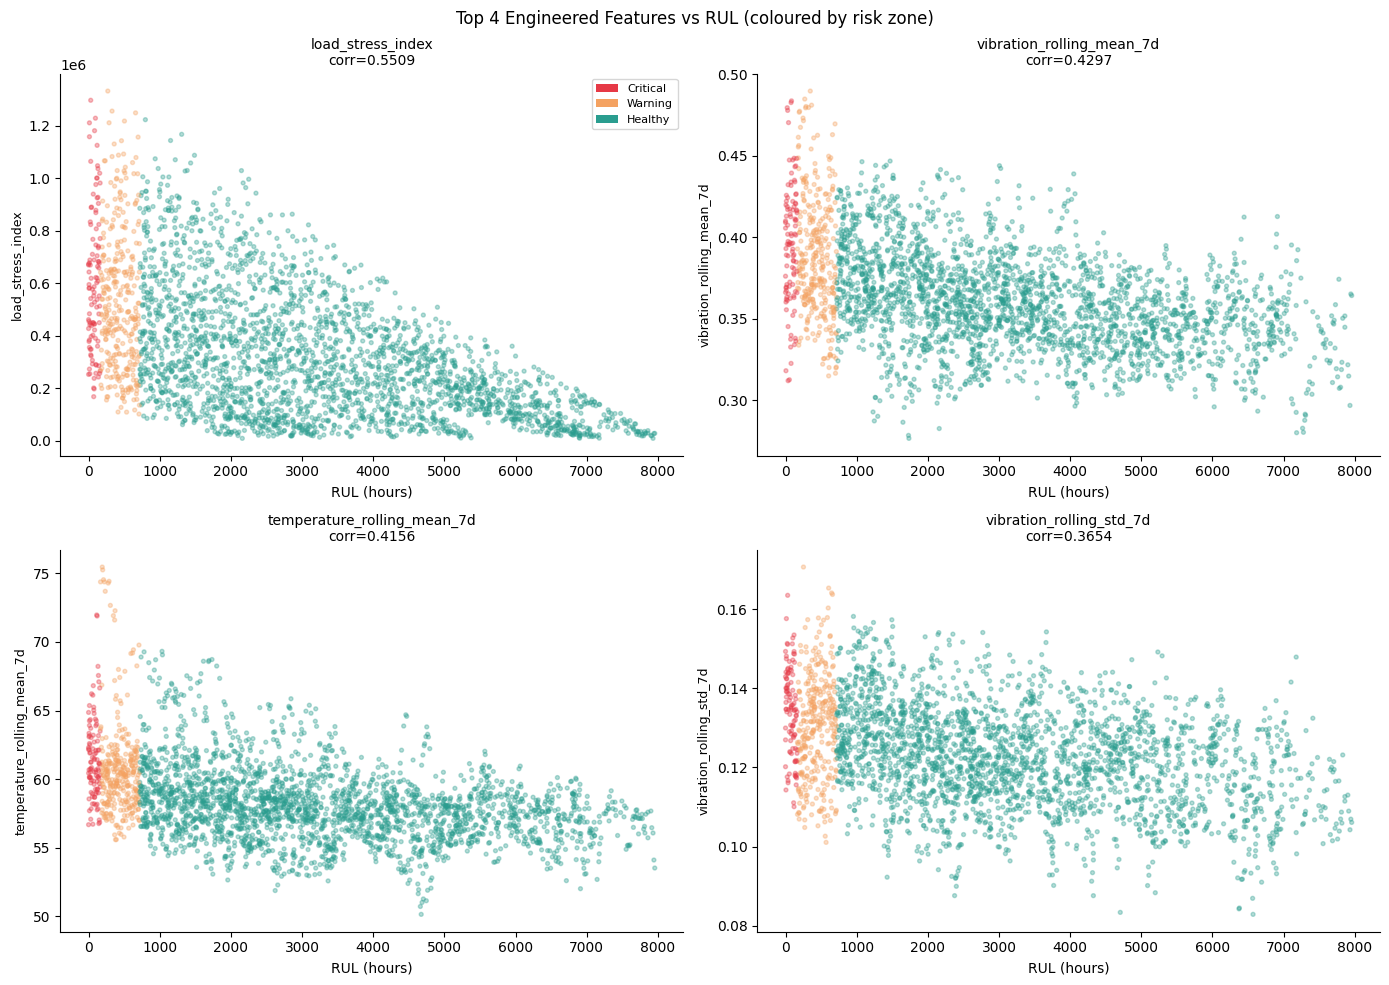

In [65]:
# Visualise key features against RUL
# We plot the 4 most correlated features against RUL.
# A clearer relationship here means the model will have stronger signal
# compared to the raw sensors in the baseline.

top_features = correlations.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    # Sample 3000 points for readability
    sample = feature_df[["rul_hours", feat, "health_risk_label"]].sample(
        n=min(3000, len(feature_df)), random_state=42
    )

    colors = sample["health_risk_label"].map({
        "Critical" : "#E63946",
        "Warning"  : "#F4A261",
        "Healthy"  : "#2A9D8F",
    })

    axes[i].scatter(
        sample["rul_hours"], sample[feat],
        c=colors, alpha=0.35, s=8
    )
    axes[i].set_xlabel("RUL (hours)", fontsize=10)
    axes[i].set_ylabel(feat, fontsize=9)
    axes[i].set_title(f"{feat}\ncorr={correlations[feat]:.4f}", fontsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)

    # Add legend once
    if i == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="#E63946", label="Critical"),
            Patch(facecolor="#F4A261", label="Warning"),
            Patch(facecolor="#2A9D8F", label="Healthy"),
        ]
        axes[i].legend(handles=legend_elements, fontsize=8, loc="upper right")

plt.suptitle("Top 4 Engineered Features vs RUL (coloured by risk zone)",
             fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/engineered_features_vs_rul.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Section 9: Feature Behaviour Validation

Before saving we run the most important check in Phase 4.

We designed these features to capture degradation behaviour as robots
approach failure. But designing a feature is not the same as proving
it works. This section validates that each engineered feature actually
behaves differently as RUL decreases toward zero.

The x-axis is inverted so the chart reads left to right as:
near failure → healthy. A feature that is working correctly will
show a rising line toward the left side of the chart.

What we expect to see:
- Rolling std features should rise near failure (more instability)
- Rolling mean features should rise near failure (higher sustained levels)
- load_stress_index should rise consistently (age × load accumulates)
- wear_trend_slope may be noisy due to sensitivity to local variation

If any feature shows a flat or downward line, it is not capturing
degradation and should be reconsidered before training.

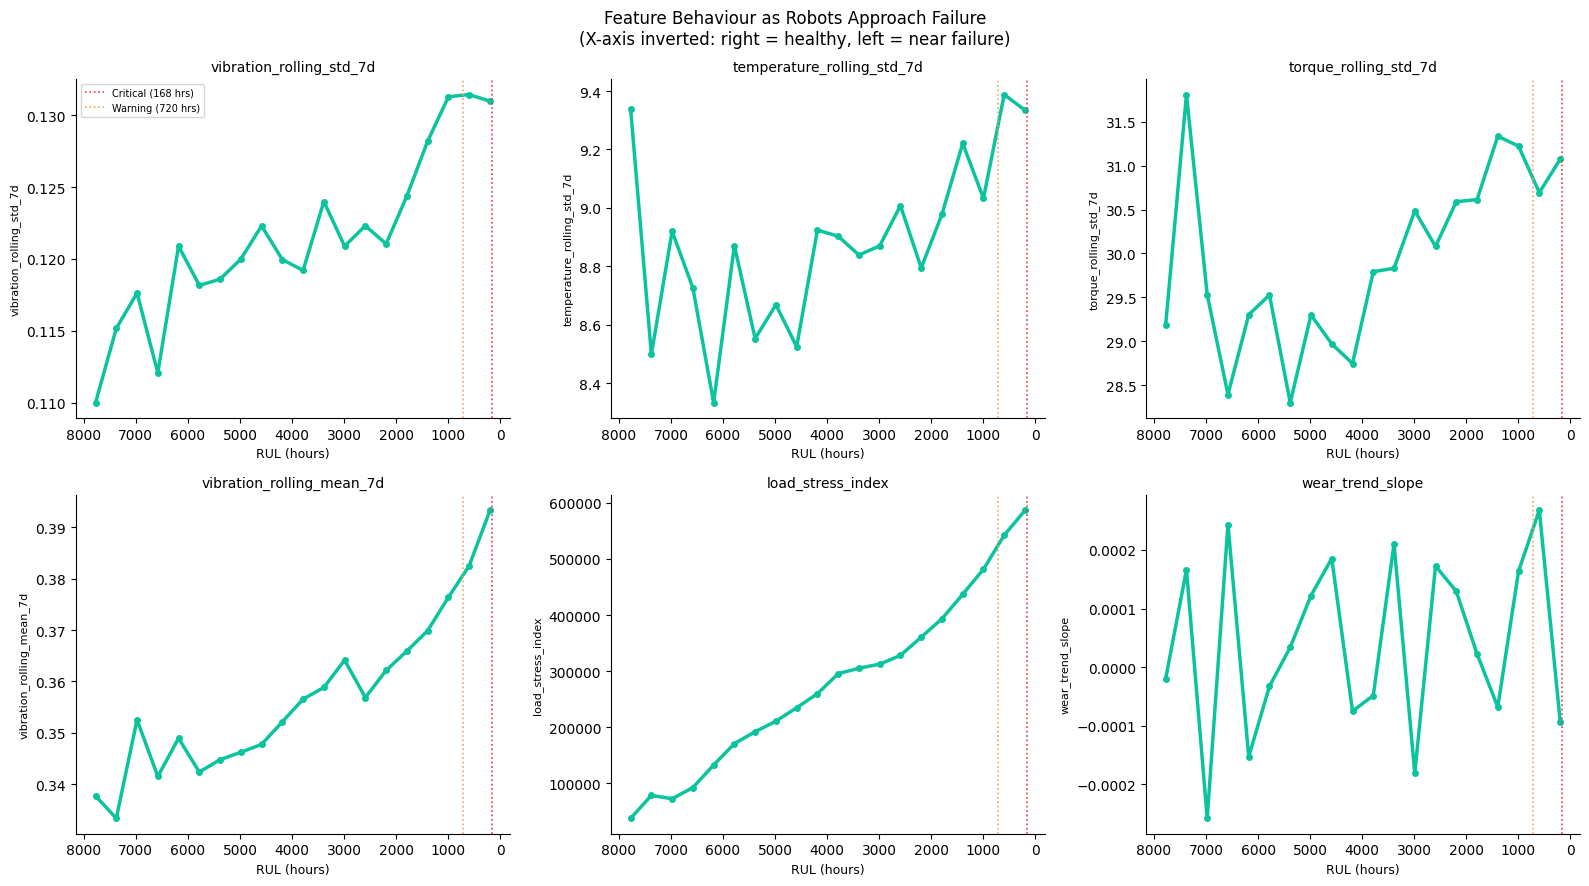

Key check: rolling_std features should rise as RUL approaches zero.
If the line rises toward the left, the feature is working as designed.


In [66]:
# Validate features behave correctly before failure
# The most important check: does rolling_std actually increase as RUL decreases?
# If it does, the feature is doing exactly what we designed it to do.
# If it does not, the feature is noise and should be reconsidered.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

validation_features = [
    "vibration_rolling_std_7d",
    "temperature_rolling_std_7d",
    "torque_rolling_std_7d",
    "vibration_rolling_mean_7d",
    "load_stress_index",
    "wear_trend_slope",
]

for i, feat in enumerate(validation_features):
    # Bin RUL into 20 equal-width buckets and compute mean feature value per bucket
    temp = feature_df[["rul_hours", feat]].copy().dropna()
    temp["rul_bin"] = pd.cut(temp["rul_hours"], bins=20)
    grouped = temp.groupby("rul_bin", observed=True)[feat].mean().reset_index()
    grouped["rul_mid"] = grouped["rul_bin"].apply(lambda x: x.mid)

    axes[i].plot(
        grouped["rul_mid"], grouped[feat],
        color="#0BC49E", linewidth=2.5, marker="o", markersize=4
    )
    axes[i].axvline(168, color="#E63946", linestyle=":", linewidth=1.2,
                    label="Critical (168 hrs)")
    axes[i].axvline(720, color="#F4A261", linestyle=":", linewidth=1.2,
                    label="Warning (720 hrs)")
    axes[i].set_xlabel("RUL (hours)", fontsize=9)
    axes[i].set_ylabel(feat, fontsize=8)
    axes[i].set_title(feat, fontsize=10)
    axes[i].invert_xaxis()
    axes[i].spines[["top", "right"]].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=7)

plt.suptitle(
    "Feature Behaviour as Robots Approach Failure\n"
    "(X-axis inverted: right = healthy, left = near failure)",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../reports/figures/feature_behaviour_vs_rul.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Key check: rolling_std features should rise as RUL approaches zero.")
print("If the line rises toward the left, the feature is working as designed.")

## Section 10: Define Feature Set for Phase 5

Phase 4 produces 15 engineered features across three groups. Not all of
them carry the same signal strength. CORE_FEATURES_V2 is the curated
subset of 12 features with the strongest confirmed signal, including both
the 7-day rolling features and the 3 new 24-hour instability features.

This is the feature set Phase 5 will use for model training.

In [67]:
# Define CORE_FEATURES_V2 — the feature set for Phase 5 and Phase 6
# 
# The original CORE_FEATURES had 9 features and excluded short-window signals.
# CORE_FEATURES_V2 adds 3 short-window (24-hour) instability features that
# give the model near-failure signal specifically for the Critical zone.
# This is the feature set Phase 5 and Phase 6 will use.

CORE_FEATURES_V2 = [
    # Strongest signal: compound wear proxy
    "load_stress_index",

    # 7-day instability signals
    "vibration_rolling_std_7d",
    "temperature_rolling_std_7d",
    "torque_rolling_std_7d",

    # 24-hour instability signals (Critical zone targeted)
    "vibration_rolling_std_24h",
    "temperature_rolling_std_24h",
    "torque_rolling_std_24h",

    # 7-day rolling means
    "vibration_rolling_mean_7d",
    "temperature_rolling_mean_7d",
    "torque_rolling_mean_7d",

    # Sudden change detection
    "vibration_short_long_diff",
    "temperature_short_long_diff",
]

ALL_ENGINEERED_FEATURES = engineered_features  # all 15 features

print(f"CORE_FEATURES_V2 ({len(CORE_FEATURES_V2)} features) — Primary set for Phase 6:")
for f in CORE_FEATURES_V2:
    corr = correlations.get(f, 0)
    print(f"  {f:<42} corr={corr:.4f}")

print(f"\nALL_ENGINEERED_FEATURES ({len(ALL_ENGINEERED_FEATURES)} features) — Full set available:")
for f in ALL_ENGINEERED_FEATURES:
    print(f"  {f}")

CORE_FEATURES_V2 (12 features) — Primary set for Phase 6:
  load_stress_index                          corr=0.5509
  vibration_rolling_std_7d                   corr=0.3654
  temperature_rolling_std_7d                 corr=0.2227
  torque_rolling_std_7d                      corr=0.2436
  vibration_rolling_std_24h                  corr=0.1221
  temperature_rolling_std_24h                corr=0.0546
  torque_rolling_std_24h                     corr=0.0522
  vibration_rolling_mean_7d                  corr=0.4297
  temperature_rolling_mean_7d                corr=0.4156
  torque_rolling_mean_7d                     corr=0.3476
  vibration_short_long_diff                  corr=0.0028
  temperature_short_long_diff                corr=0.0094

ALL_ENGINEERED_FEATURES (15 features) — Full set available:
  vibration_rolling_mean_7d
  vibration_rolling_std_7d
  temperature_rolling_mean_7d
  temperature_rolling_std_7d
  torque_rolling_mean_7d
  torque_rolling_std_7d
  power_rolling_mean_7d
  power_ro

## Section 11: Save Featured Dataset

We save the final engineered dataset to data/processed/featured_dataset.csv.

This dataset is the direct input for Phase 5 engineered model training.
It contains 15 engineered features designed to capture degradation patterns
that raw sensor values cannot reveal.

Final dataset summary:
- Original rul_dataset.csv      : 15,245 rows
- After NaN drop                : 14,786 rows
- Rows removed                  : 459 (27 warm-up rows × 17 robots)
- Total engineered features     : 15
- Total columns                 : 40
- All 17 failure robots retained
- RUL range preserved           : 0 to 7,974 hours


In [68]:
# ─── Save featured_dataset.csv ────────────────────────────────────────────────
# This is the final output of Phase 4 and the direct input for Phase 6.
# The dataset now contains 15 engineered features:
# - 8 rolling features (7-day mean and std for all 4 sensors)
# - 4 compound features (wear slope, load stress, short-long diffs)
# - 3 short-window features (24-hour std for vibration, temperature, torque)

import os

os.makedirs("../data/processed", exist_ok=True)

feature_df.to_csv("../data/processed/featured_dataset.csv", index=False)

file_path = "../data/processed/featured_dataset.csv"
assert os.path.exists(file_path), "Save failed. File not found."

file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

print("featured_dataset.csv saved.")
print(f"  Location  : data/processed/featured_dataset.csv")
print(f"  Shape     : {feature_df.shape}")
print(f"  File size : {file_size_mb:.1f} MB")
print(f"  Robots    : {feature_df['robot_id'].nunique()}")
print(f"  RUL range : {feature_df['rul_hours'].min():.0f} to {feature_df['rul_hours'].max():.0f} hours")

print(f"\nAll engineered features ({len(engineered_features)}):")
for col in engineered_features:
    print(f"  {col}")

print(f"\nCORE_FEATURES_V2 for Phase 6 ({len(CORE_FEATURES_V2)}):")
for col in CORE_FEATURES_V2:
    print(f"  {col}")

featured_dataset.csv saved.
  Location  : data/processed/featured_dataset.csv
  Shape     : (14786, 40)
  File size : 7.0 MB
  Robots    : 17
  RUL range : 0 to 7974 hours

All engineered features (15):
  vibration_rolling_mean_7d
  vibration_rolling_std_7d
  temperature_rolling_mean_7d
  temperature_rolling_std_7d
  torque_rolling_mean_7d
  torque_rolling_std_7d
  power_rolling_mean_7d
  power_rolling_std_7d
  wear_trend_slope
  load_stress_index
  vibration_short_long_diff
  temperature_short_long_diff
  vibration_rolling_std_24h
  temperature_rolling_std_24h
  torque_rolling_std_24h

CORE_FEATURES_V2 for Phase 6 (12):
  load_stress_index
  vibration_rolling_std_7d
  temperature_rolling_std_7d
  torque_rolling_std_7d
  vibration_rolling_std_24h
  temperature_rolling_std_24h
  torque_rolling_std_24h
  vibration_rolling_mean_7d
  temperature_rolling_mean_7d
  torque_rolling_mean_7d
  vibration_short_long_diff
  temperature_short_long_diff


## Phase 4 Summary

### What Was Built in This Phase

15 engineered features were built across three groups. Each feature was
designed based on the EDA finding that failure is preceded by instability
and behavioural change over time, not by absolute sensor values at any
single moment.

| Feature | Type | Window | Signal Captured |
|---|---|---|---|
| vibration_rolling_mean_7d | Rolling mean | 7 days | Sustained vibration trend |
| vibration_rolling_std_7d | Rolling std | 7 days | Vibration instability (primary signal) |
| temperature_rolling_mean_7d | Rolling mean | 7 days | Sustained thermal load |
| temperature_rolling_std_7d | Rolling std | 7 days | Thermal instability |
| torque_rolling_mean_7d | Rolling mean | 7 days | Mechanical load trend |
| torque_rolling_std_7d | Rolling std | 7 days | Torque instability |
| power_rolling_mean_7d | Rolling mean | 7 days | Energy consumption trend |
| power_rolling_std_7d | Rolling std | 7 days | Power instability |
| vibration_rolling_std_24h | Rolling std | 24 hours | Near-failure vibration instability |
| temperature_rolling_std_24h | Rolling std | 24 hours | Near-failure thermal instability |
| torque_rolling_std_24h | Rolling std | 24 hours | Near-failure torque instability |
| wear_trend_slope | Regression slope | 7 days | Rate of change in vibration |
| load_stress_index | Compound | None | Torque × cumulative hours |
| vibration_short_long_diff | Diff | 24hr vs 7d | Sudden vibration spike detection |
| temperature_short_long_diff | Diff | 24hr vs 7d | Sudden thermal event detection |

The 7-day rolling features capture sustained behaviour over the past week.
The 24-hour rolling features capture very recent instability specifically
within the Critical zone timescale. Both timescales are needed because
in the Critical zone (RUL < 168 hours), a 7-day window looks further
back than the robot's remaining life, diluting the near-failure signal
with older healthy behaviour.

---

### Leakage Validation Results

All checks passed before saving:

- Data sorted by robot_id and timestamp before all rolling operations
- All rolling windows grouped by robot_id, no cross-robot contamination
- 7-day features: 27 NaN warm-up rows per robot = 459 rows total
- 24-hour features: 3 NaN warm-up rows per robot = fully covered by 7-day drop
- load_stress_index: zero NaN (no rolling window involved)
- Zero NaN remaining after combined drop
- All 17 robots retained after drop

---

### Feature Behaviour Validation

Each feature was plotted against RUL with x-axis inverted to confirm
it behaves as designed. Right side of chart = healthy robot. Left side
= near failure. A working feature shows a rising line toward the left.

| Feature | Behaviour Toward Failure | Verdict |
|---|---|---|
| load_stress_index | Near-perfect linear rise | Strongest signal |
| vibration_rolling_mean_7d | Strong clean rise | Working as designed |
| vibration_rolling_std_7d | Consistent rise | Working as designed |
| temperature_rolling_std_7d | Upward trend, moderate noise | Working |
| torque_rolling_std_7d | Upward trend, moderate noise | Working |
| wear_trend_slope | Noisy, no clear trend | Retained but low priority |

The 24-hour std features were not separately plotted here as they were
added specifically to target near-failure behaviour where the 7-day window
loses precision. Their value will be confirmed in Phase 5 model evaluation.

---

### Feature Correlation with RUL

| Feature | Correlation | Note |
|---|---|---|
| load_stress_index | 0.551 | Strongest. Compound wear proxy. |
| vibration_rolling_mean_7d | 0.430 | 7-day smoothing improves on raw sensor |
| temperature_rolling_mean_7d | 0.416 | Sustained thermal signal |
| vibration_rolling_std_7d | 0.365 | Primary instability signal from EDA |
| torque_rolling_mean_7d | 0.348 | Mechanical load trend |
| torque_rolling_std_7d | 0.244 | Torque instability |
| temperature_rolling_std_7d | 0.223 | Thermal instability |
| power_rolling_mean_7d | 0.144 | Weak but retained |
| power_rolling_std_7d | 0.080 | Weak but retained |
| vibration_short_long_diff | 0.003 | Non-linear signal, tree models can exploit |
| temperature_short_long_diff | 0.009 | Non-linear signal, tree models can exploit |
| wear_trend_slope | 0.009 | Noisy. Low priority in feature selection. |

Note: Low linear correlation on the short-long diff features and the
24-hour features does not mean they are useless. Linear correlation only
captures monotonic relationships. Tree-based models detect non-linear
patterns that correlation cannot measure. Their true contribution will
be confirmed by comparing model performance in Phase 5.

---

### Feature Set Defined for Phase 5

CORE_FEATURES_V2 contains the 12 highest-signal features from this phase.
It is the primary feature set Phase 5 will use for model training.

It includes both the 7-day instability features and the 3 new 24-hour
instability features, giving the model signal at two timescales.
The 7-day features capture sustained degradation. The 24-hour features
capture the rapid instability that occurs in the final days before failure.

Features excluded from CORE_FEATURES_V2:
- wear_trend_slope: noisy, near-zero correlation, computationally expensive
- power_rolling_mean_7d: weakest signal in the dataset
- power_rolling_std_7d: weakest signal in the dataset

These three are still present in the dataset and available for future
experimentation but are not included in the primary training set.

---

### Dataset Output

| | Before | After |
|---|---|---|
| Source file | rul_dataset.csv | featured_dataset.csv |
| Rows | 15,245 | 14,786 |
| Columns | 25 | 40 |
| Robots | 17 | 17 |
| Rows dropped | 0 | 459 |
| Engineered features | 0 | 15 |

---

### Next Step: Phase 5 Engineered Model Training

Load featured_dataset.csv. Apply the same robot-level train/test split
as Phase 3 to ensure the comparison is fair. Retrain Random Forest and
Gradient Boosting using CORE_FEATURES_V2 (12 features) combined with
the Baseline B feature set (16 features), giving 28 input features.

The primary question Phase 5 must answer:

Do the 15 engineered features improve prediction performance beyond
the Phase 3 baseline, particularly in the Critical zone?

Benchmarks to beat (from Phase 3 baseline):
- Overall MAE below 659.7 hours
- Overall R² above 0.855
- Critical MAE below 59.1 hours
- Minimum lead time at or above 384 hours
- Zero missed detections (non-negotiable)